In [12]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax
import dLux as dl

print("jax version:", jax.__version__)
# print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)

cpu
64bit enabled
jax version: 0.8.3
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10


# Loading in data

In [13]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    if gethostname().startswith("max-"):
        jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    else:
        jax.config.update("jax_compilation_cache_dir", "/fred/oz440/max/jax_cache")

    jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 500
n_files_per_filt = 3
one_filt_flag = False
pos1_only = True
plot_flag = check_script()
save_flag = check_script()

if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpuv3-0-18
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [14]:
from retrain_fns import summarise_files
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    # if file[0].header["PROGRAM"] == "04481" and file[0].header["FILTER"] == "F430M":
    #     file["BADPIX"].data[30, 40] = 1
    return file


## Validation files
Calibrators from other science programs

In [15]:
from amigo.misc import get_pos
from importlib import resources

badpix = np.array(np.load(resources.files("amigo") / "data" / "badpix.npy"), dtype=float)


def sort_files(files, n):
    files.sort(key=lambda x: (x[0].header["PROGRAM"], x[0].header["FILTER"], x[0].header["PATT_NUM"]), reverse=True)
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}
    for filt in filts:
        x = []
        for file in files:
            if file[0].header["FILTER"] == filt:
                if one_filt_flag and filt != "F480M":
                    continue
                if pos1_only and get_pos(file) != "POS1":
                    continue
                x.append(file)
        these_files[filt] = x[0:n]
    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

## Calibration files
The main training data, including flats.

In [16]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

calpsf_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files
calpsf_files = [add_badpix(file) for file in calpsf_files]
calpsf_files = sort_files(calpsf_files, n_files_per_filt)
summarise_files(calpsf_files)

CAL4481 - Anand Sivaramakrishnan
  program    target filter dither      g/i        date                       PI   CAL
0    4481  HD-41094  F480M    3/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1    4481  HD-41094  F480M    4/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
2    4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
3    4481  HD-41094  F380M    3/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
4    4481  HD-41094  F380M    4/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
5    4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
6    4481  HD-41094  F430M    3/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
7    4481  HD-41094  F430M    4/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
8    4481  HD-41094  F430M    5/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True


Flats.

# Exposures

In [17]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
calpsf_exposures = [PointFit(file) for file in calpsf_files]
exposures = [*calpsf_exposures]

Finally, let's batch the exposures for training.

# Building model

In [18]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from retrain_fns import nn_setup_options

config = int(job_index)
# config = 0
nn_arch = nn_setup_options[config]

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(**nn_arch),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

model = model.set("FF", np.ones_like(model.FF))

try:
    weights = np.load(amigo_files_path + f"/scratch_distill_{config}.npy")
    model = model.set("nn_weights", weights)
except:
    pass


print(weights.shape)

(8640,)


Populate from state.

In [19]:
from amigo.fitting import sgd, adam
from zodiax import optimisation as opt
import equinox as eqx
from tqdm.auto import tqdm
import optax

illums = load_dict(amigo_files_path + "/illums.npy")
ramps = load_dict(amigo_files_path + "/ramps.npy")
pixel_scale = 6e-06

def one_exp_loss(model, exposure):
    illum = dl.PSF(illums[exposure.key], pixel_scale)
    old_ramp = ramps[exposure.key]
    new_ramp = exposure.model_ramp(illum, model).data
    return -np.nansum(jax.scipy.stats.norm.logpdf(new_ramp, loc=old_ramp))

def loss_fn(params, args):
    print("Compiling loss_fn...")
    model, exposures = args
    model = model.set("nn_weights", params["nn_weights"])
    losses = [one_exp_loss(model, exp) for exp in exposures]
    return np.array(losses).mean()

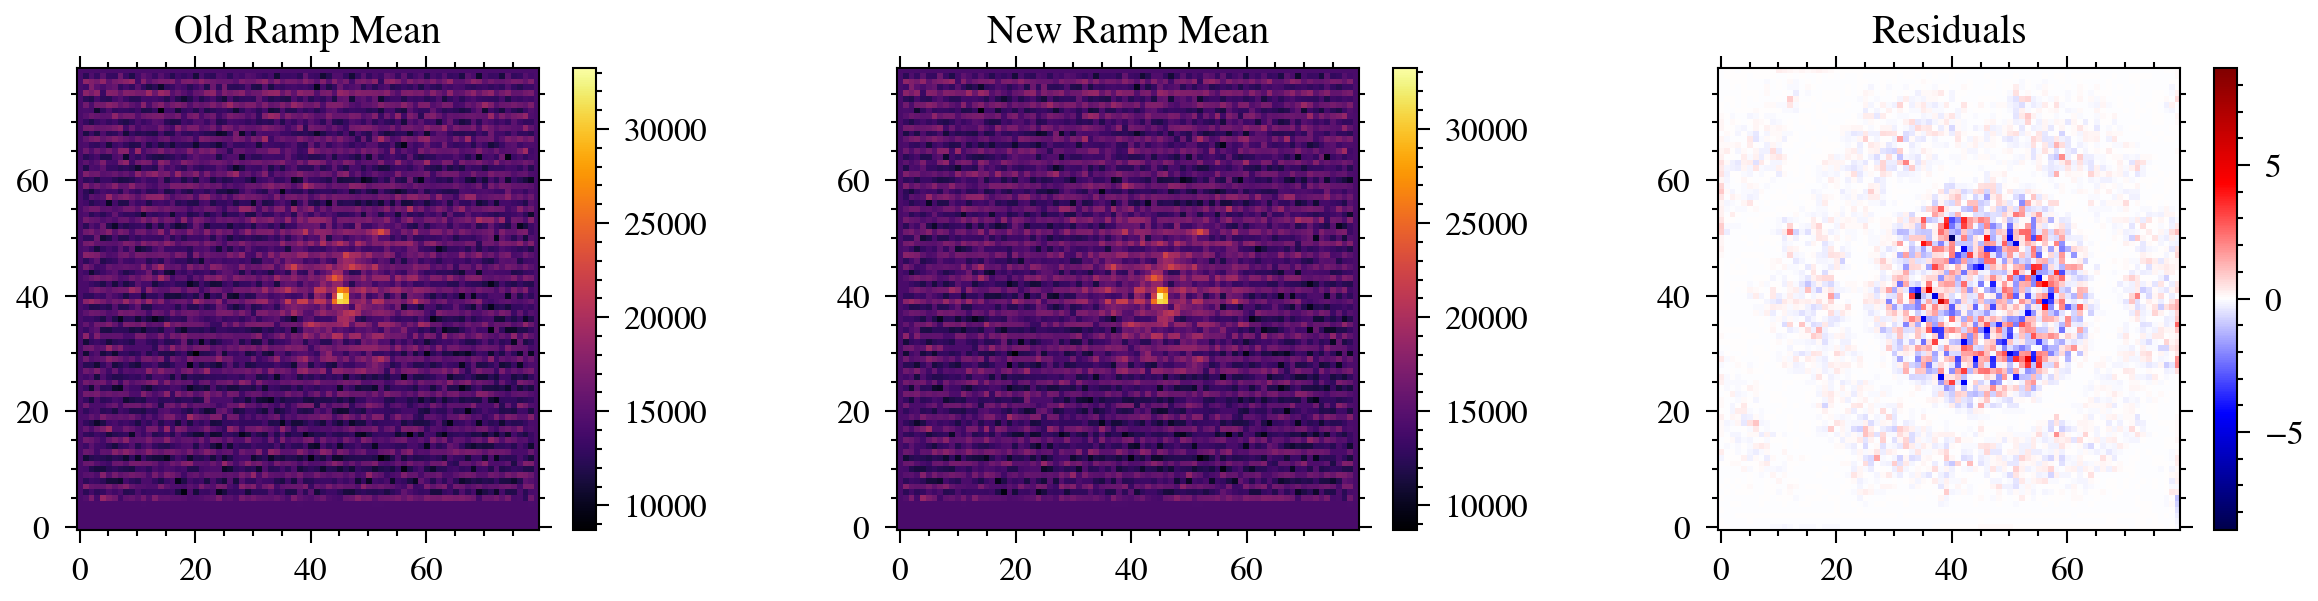

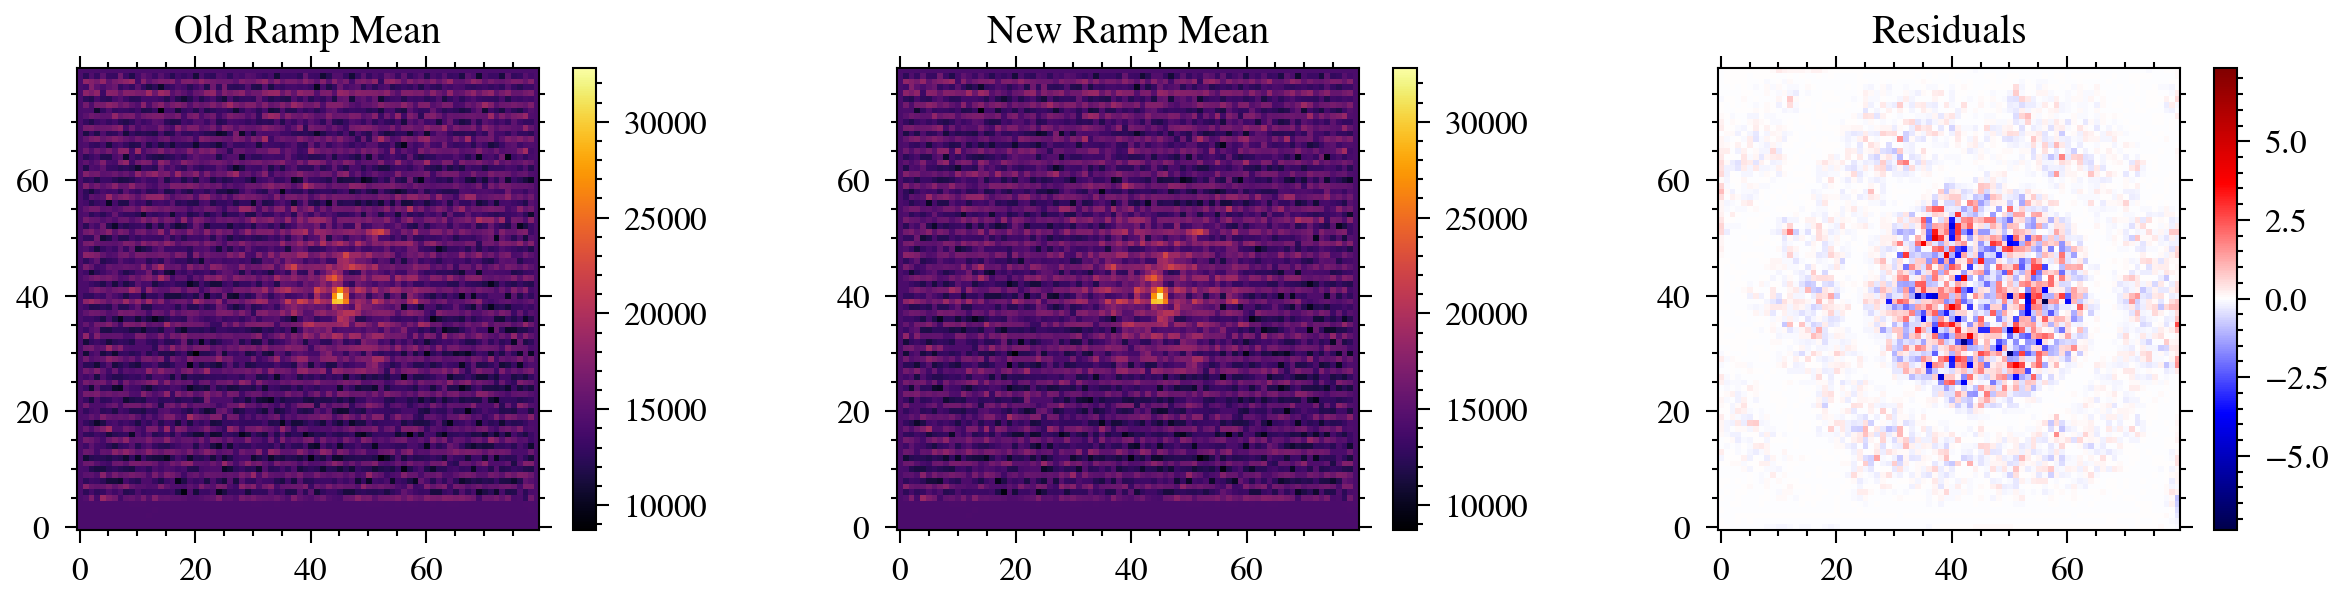

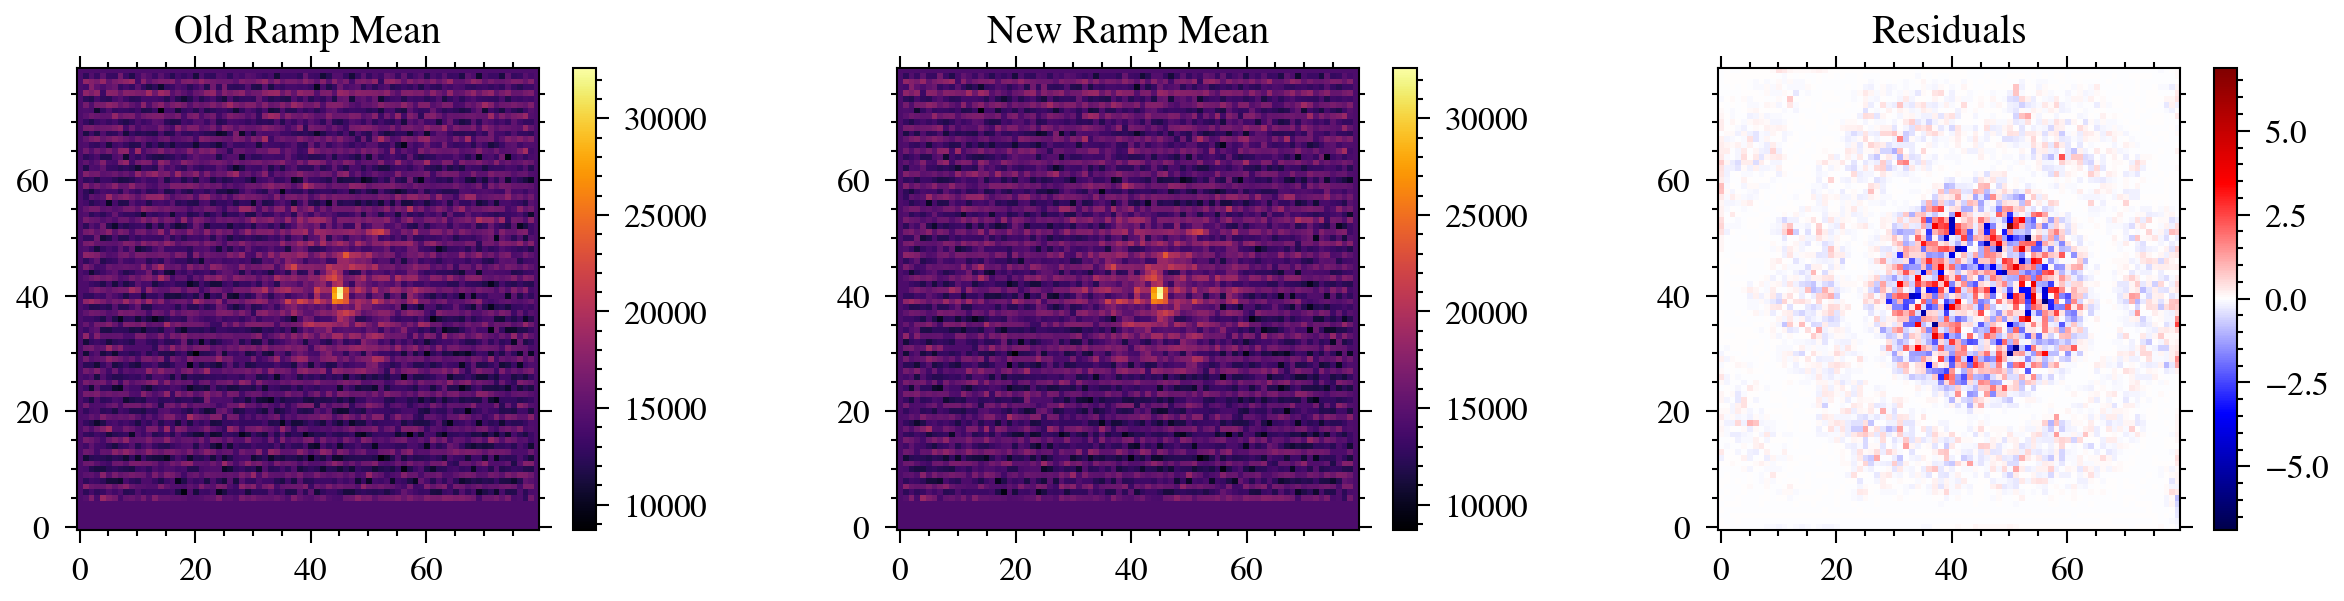

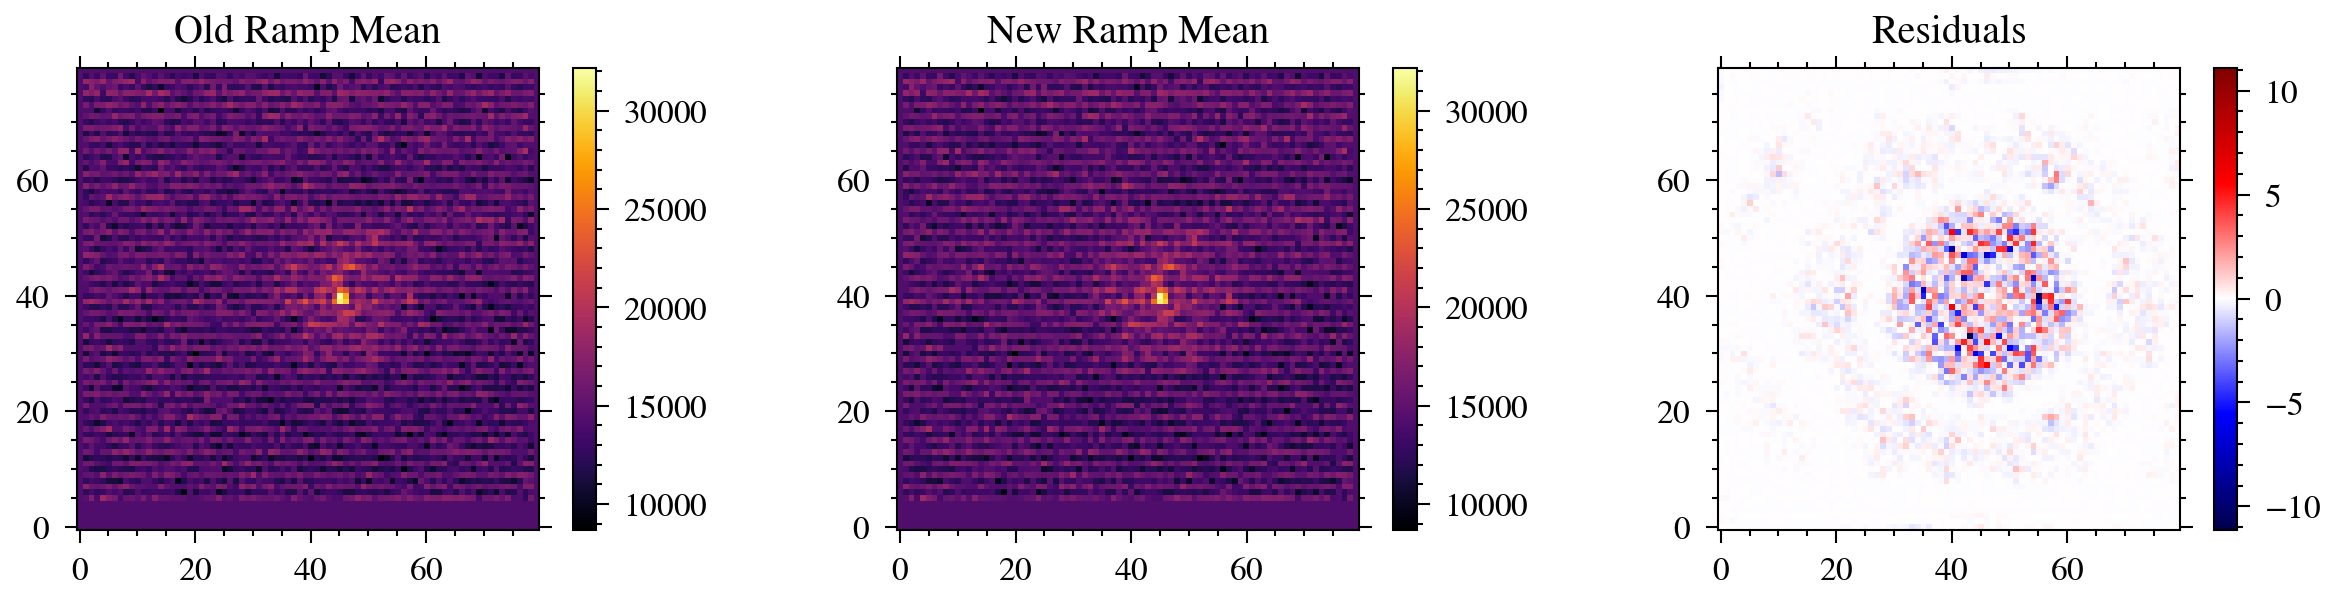

KeyboardInterrupt: 

In [20]:
for exposure in exposures:
    if save_flag:
        this_save_path = os.path.join(save_path, "init_cal")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
        
    illum = dl.PSF(illums[exposure.key], pixel_scale)
    old_ramp = ramps[exposure.key]
    new_ramp = exposure.model_ramp(illum, model).data

    fig, ax = plt.subplots(1, 3, figsize=(10, 2))

    im = ax[0].imshow(old_ramp.mean(0), inferno)
    fig.colorbar(im)
    ax[0].set(
        title="Old Ramp Mean",
    )
    
    im = ax[1].imshow(new_ramp.mean(0), inferno)
    fig.colorbar(im)
    ax[1].set(
        title="New Ramp Mean",
    )
    
    im = ax[2].imshow((old_ramp - new_ramp).mean(0), seismic, norm=mpl.colors.CenteredNorm())
    fig.colorbar(im)
    ax[2].set(
        title="Residuals",
    )

    if save_flag:
        plt.savefig(os.path.join(this_save_path, f"{exposure.key}.png"))
        plt.close()
    else:
        plt.show()

In [ ]:
# JIT and grad transform the loss function
loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn))

# Define our optimisers that we map to each parameter
optimisers = {
    "nn_weights": optax.sgd(1e-9, momentum=0.5),
}

params = {"nn_weights": model.nn_weights}

# Now we map the optimisers to the parameters and get the initial state
optim, state = opt.map_optimisers(params, optimisers, strict=True)

# Bundle up the arguments
args = (model, exposures)
# init_loss = loss_fn(params, args)

# Now we can run a simple optimisation loop
losses = []
progress_bar = tqdm(range(epochs), desc=f"Loss: ")

for step in progress_bar:
    loss, grads = loss_grad_fn(params, args)
    updates, state = optim.update(grads, state, params)
    params = optax.apply_updates(params, updates)
    
    losses.append(loss)
    progress_bar.set_description(f"Loss: {loss:.4e}")
losses = np.array(losses)

In [ ]:
np.save(amigo_files_path + f"/scratch_distill_{config}.npy", params["nn_weights"])


fig, ax = plt.subplots(1, 2, figsize=(6, 2))

ax[0].hist(model.nn_weights.ravel(), bins=300)
ax[0].hist(params["nn_weights"].ravel(), bins=300)

ax[1].plot(losses)
ax[1].set(
    title="Loss Curve",
    xlabel="Epoch",
    ylabel="Loss",
)
if save_flag:
    plt.savefig(os.path.join(save_path, f"{losses}.png"))
    plt.close()
else:
    plt.show()
    

In [ ]:
result_model = model.set("nn_weights", params["nn_weights"])

for exposure in exposures:

    if save_flag:
        this_save_path = os.path.join(save_path, "cal")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
        
    illum = dl.PSF(illums[exposure.key], pixel_scale)
    old_ramp = ramps[exposure.key]
    new_ramp = exposure.model_ramp(illum, result_model).data

    fig, ax = plt.subplots(1, 3, figsize=(10, 2))

    im = ax[0].imshow(old_ramp.mean(0), inferno)
    fig.colorbar(im)
    ax[0].set(
        title="Old Ramp Mean",
    )
    
    im = ax[1].imshow(new_ramp.mean(0), inferno)
    fig.colorbar(im)
    ax[1].set(
        title="Fit New Ramp Mean",
    )
    
    im = ax[2].imshow((old_ramp - new_ramp).mean(0), seismic, norm=mpl.colors.CenteredNorm())
    fig.colorbar(im)
    ax[2].set(
        title="Residuals",
    )
    
    if save_flag:
        plt.savefig(os.path.join(this_save_path, f"{exposure.key}.png"))
        plt.close()
    else:
        plt.show()